In [ ]:
import numpy as np 
import pandas as pd 
from scipy import stats 
import os
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
path = r"Enter Path"
#Enter the path to the dataset folder inside the " ".

Importing Datasets

In [3]:
df_item = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
df_reviews = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
df_orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
df_products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
df_geolocation = pd.read_csv(os.path.join(path, "olist_geolocation_dataset.csv"))
df_sellers = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
df_order_pay = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
df_customers = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
df_category = pd.read_csv(os.path.join(path, "product_category_name_translation.csv"))

Merging Datasets

In [6]:
df_train = df_orders.merge(df_item, on='order_id', how='left')
df_train = df_train.merge(df_order_pay, on='order_id', how='outer', validate='m:m')
df_train = df_train.merge(df_reviews, on='order_id', how='outer')
df_train = df_train.merge(df_products, on='product_id', how='outer')
df_train = df_train.merge(df_customers, on='customer_id', how='outer')
df_train = df_train.merge(df_sellers, on='seller_id', how='outer')

print(df_train.shape)

(119143, 39)


Handling Null Values

In [7]:
df_train.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3
review_id                           997
review_score                        997
review_comment_title             105154
review_comment_message            68898
review_creation_date                997
review_answer_timestamp             997
product_category_name              2542


Removing Uneccessary rows to get rid of null values

In [8]:
df_train.dropna(subset = ['order_item_id'], inplace=True)
df_train.dropna(subset = ['payment_type'], inplace=True)
df_train.dropna(subset = ['review_id'], inplace=True)

Filling remaining Null Values

In [9]:
df_train.review_comment_title = df_train.review_comment_title.fillna("Empty")
df_train.review_comment_message = df_train.review_comment_message.fillna("Empty")
df_train.review_score = df_train.review_score.fillna(0)
df_train.product_category_name = df_train.product_category_name.fillna("N/A")
df_train.product_name_lenght = df_train.product_name_lenght.fillna(0)
df_train.product_description_lenght = df_train.product_description_lenght.fillna(0)
df_train.product_photos_qty = df_train.product_photos_qty.fillna(0)
df_train.product_weight_g = df_train.product_weight_g.fillna('Unknown')
df_train.product_length_cm = df_train.product_length_cm.fillna('Unknown')
df_train.product_height_cm = df_train.product_height_cm.fillna('Unknown')
df_train.product_width_cm = df_train.product_width_cm.fillna('Unknown')


Changing data type to Dates.

In [10]:
df_train['order_delivered_carrier_date'] = pd.to_datetime(df_train['order_delivered_carrier_date'])
df_train['order_delivered_customer_date'] = pd.to_datetime(df_train['order_delivered_customer_date'])
df_train['order_estimated_delivery_date'] = pd.to_datetime(df_train['order_estimated_delivery_date'])
df_train['shipping_limit_date'] = pd.to_datetime(df_train['shipping_limit_date'])
df_train['review_creation_date'] = pd.to_datetime(df_train['review_creation_date'])
df_train['order_approved_at'] = pd.to_datetime(df_train['order_approved_at'])
df_train['order_purchase_timestamp'] = pd.to_datetime(df_train['order_purchase_timestamp'])
df_train['order_delivered_customer_date'] = pd.to_datetime(df_train['order_delivered_customer_date'])
df_train['order_delivered_carrier_date'] = pd.to_datetime(df_train['order_delivered_carrier_date'])




Delivery Time Analysis

In [11]:
Delivery_time = df_train['order_delivered_customer_date'] - df_train['order_approved_at']
df_train['Delivery_time'] = Delivery_time

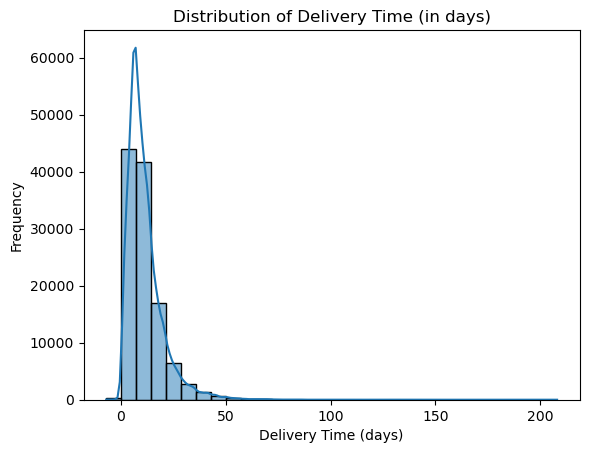

In [12]:
sns.histplot(df_train['Delivery_time'].dt.days, bins=30, kde=True)
plt.title('Distribution of Delivery Time (in days)')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Frequency')
plt.show()

In [13]:
""" Most of the deliveries are done under 50 days which is fine. """

' Most of the deliveries are done under 50 days which is fine. '

Handling Outliers

Text(0.5, 0, 'Payment Value')

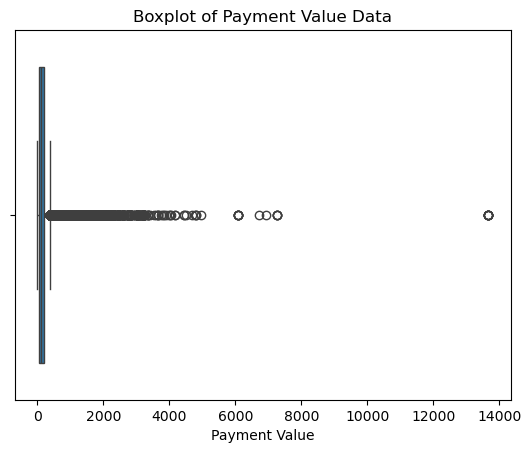

In [14]:
sns.boxplot(x = df_train['payment_value'])
plt.title('Boxplot of Payment Value Data')
plt.xlabel('Payment Value')

Getting rid of outliers

In [15]:
payment_value_cleaned = []
q1 = df_train['payment_value'].quantile(0.25)
q3 = df_train['payment_value'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
for i in df_train['payment_value']:
    if i > lower_bound and i < upper_bound:
        payment_value_cleaned.append(i)

Text(0.5, 0, 'Payment Value')

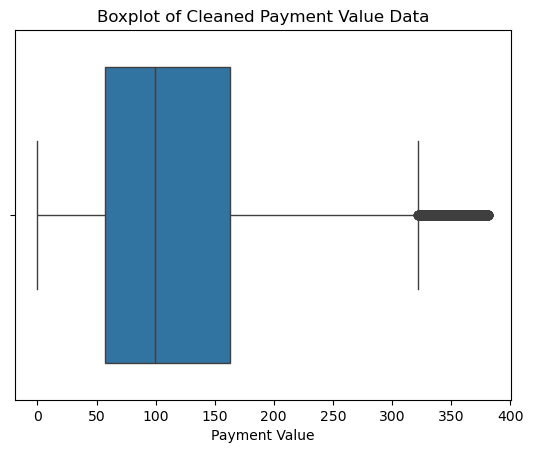

In [16]:
sns.boxplot(x = payment_value_cleaned)
plt.title('Boxplot of Cleaned Payment Value Data')
plt.xlabel('Payment Value')

Text(0.5, 0, 'Price')

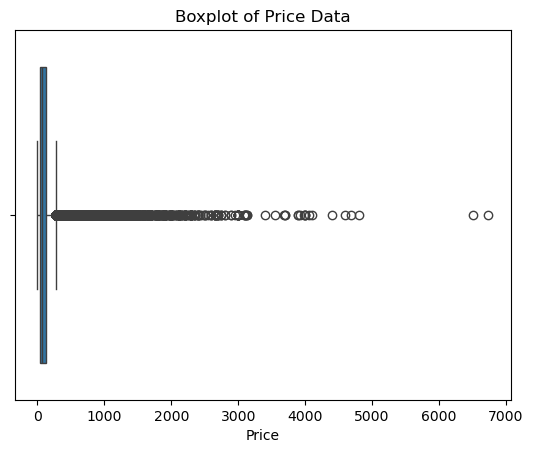

In [17]:
sns.boxplot(x = df_train['price'])
plt.title('Boxplot of Price Data')
plt.xlabel('Price')

Getting rid of outliers

In [18]:
q1 = df_train['price'].quantile(0.25)
q3 = df_train['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
price_cleaned = []
for i in df_train['price']:
    if i > lower_bound and i < upper_bound:
        price_cleaned.append(i)

Text(0.5, 0, 'Price')

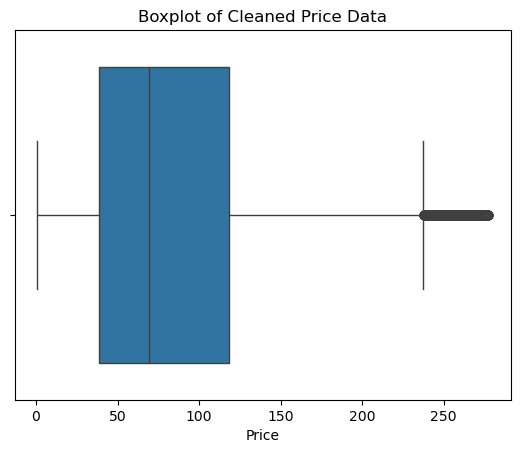

In [19]:
sns.boxplot(x = price_cleaned)
plt.title('Boxplot of Cleaned Price Data')
plt.xlabel('Price')

Comparison between cleaned price and cleaned Payment value

In [20]:
cleaned_price_ds = pd.Series(price_cleaned)
cleaned_payment_ds = pd.Series(payment_value_cleaned)
x = cleaned_price_ds.describe()
y = cleaned_payment_ds.describe()
comp_df = pd.DataFrame({'Price': x, 'Payment Value': y})
comp_df = comp_df.drop('count')
ndf = comp_df.reset_index()
mndf = ndf.melt(id_vars='index', var_name='Metric', value_name='Value')
ndf

,index,Price,Payment Value
0,mean,83.792866,119.686370
1,std,58.492151,81.339495
2,min,0.850000,0.000000
3,25%,38.500000,57.290000
4,50%,69.000000,99.735000
5,75%,118.130000,163.310000
6,max,277.300000,381.510000


Text(0.5, 0, 'Metric')

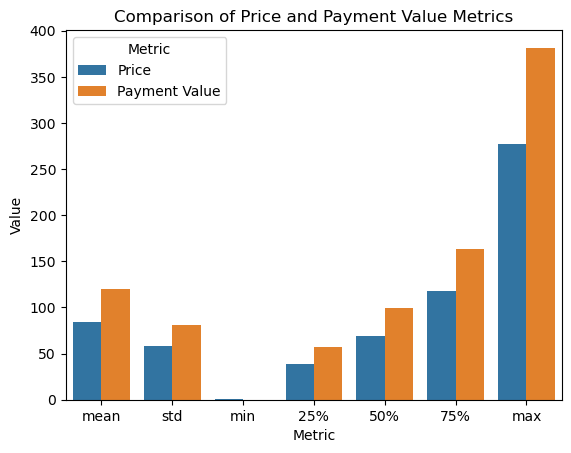

In [21]:
sns.barplot(data=mndf, x='index', y='Value', hue='Metric')
plt.title('Comparison of Price and Payment Value Metrics')
plt.xlabel('Metric')

Status of Undelivered products

In [22]:
ddf = df_train.groupby('order_status').size().reset_index(name='counts')
ddf = ddf.drop(2)
ddf

,order_status,counts
0,approved,3
1,canceled,553
3,invoiced,370
4,processing,370
5,shipped,1167
6,unavailable,7


C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\2294355456.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = ddf, x='order_status', y='counts', palette = ["#05E6FF","#FF0000","#DFFF41",'#FFCC99', "#28FF02", "#FD0000"])


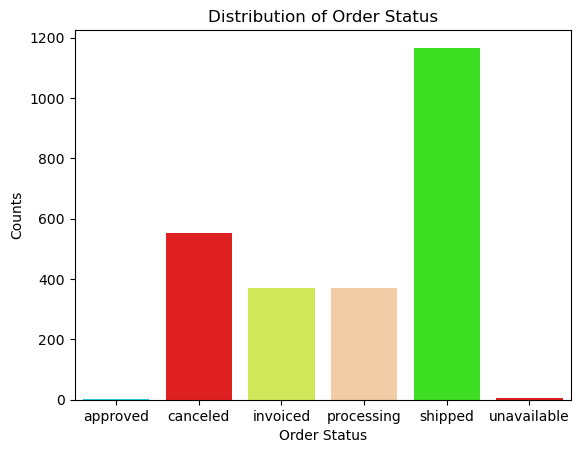

In [23]:
sns.barplot(data = ddf, x='order_status', y='counts', palette = ["#05E6FF","#FF0000","#DFFF41",'#FFCC99', "#28FF02", "#FD0000"])
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Counts')
plt.show()

In [24]:
"""The Rate of Canceled orders is much high."""

'The Rate of Canceled orders is much high.'

In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117329 entries, 0 to 118309
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       117329 non-null  object         
 1   customer_id                    117329 non-null  object         
 2   order_status                   117329 non-null  object         
 3   order_purchase_timestamp       117329 non-null  datetime64[ns] 
 4   order_approved_at              117314 non-null  datetime64[ns] 
 5   order_delivered_carrier_date   116094 non-null  datetime64[ns] 
 6   order_delivered_customer_date  114858 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  117329 non-null  datetime64[ns] 
 8   order_item_id                  117329 non-null  float64        
 9   product_id                     117329 non-null  object         
 10  seller_id                      117329 non-null  object       

Reviews Comparison

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\3359407770.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = rdf, x='review_score', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])


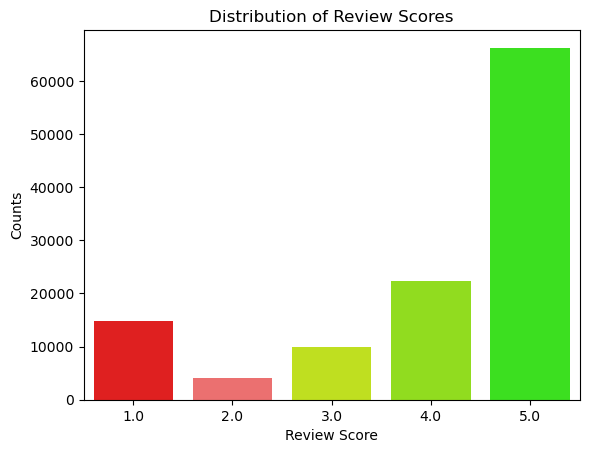

In [26]:
rdf = df_train.groupby('review_score').size().reset_index(name='counts')
rdf
sns.barplot(data = rdf, x='review_score', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Counts')
plt.show()

In [27]:
"""Most of the reviews are positive but 1.0 reviews are high"""

'Most of the reviews are positive but 1.0 reviews are high'

Analysis of deliveries made by time.

In [28]:
rvdfy = df_train.groupby([df_train['order_delivered_customer_date'].dt.to_period('Y')]).size().reset_index(name='counts')
rvdf = df_train.groupby([df_train['order_delivered_customer_date'].dt.to_period('M')]).size().reset_index(name='counts')
rvdf16 = rvdf[rvdf['order_delivered_customer_date'].dt.year == 2016]
rvdf17 = rvdf[rvdf['order_delivered_customer_date'].dt.year == 2017]
rvdf18 = rvdf[rvdf['order_delivered_customer_date'].dt.year == 2018]

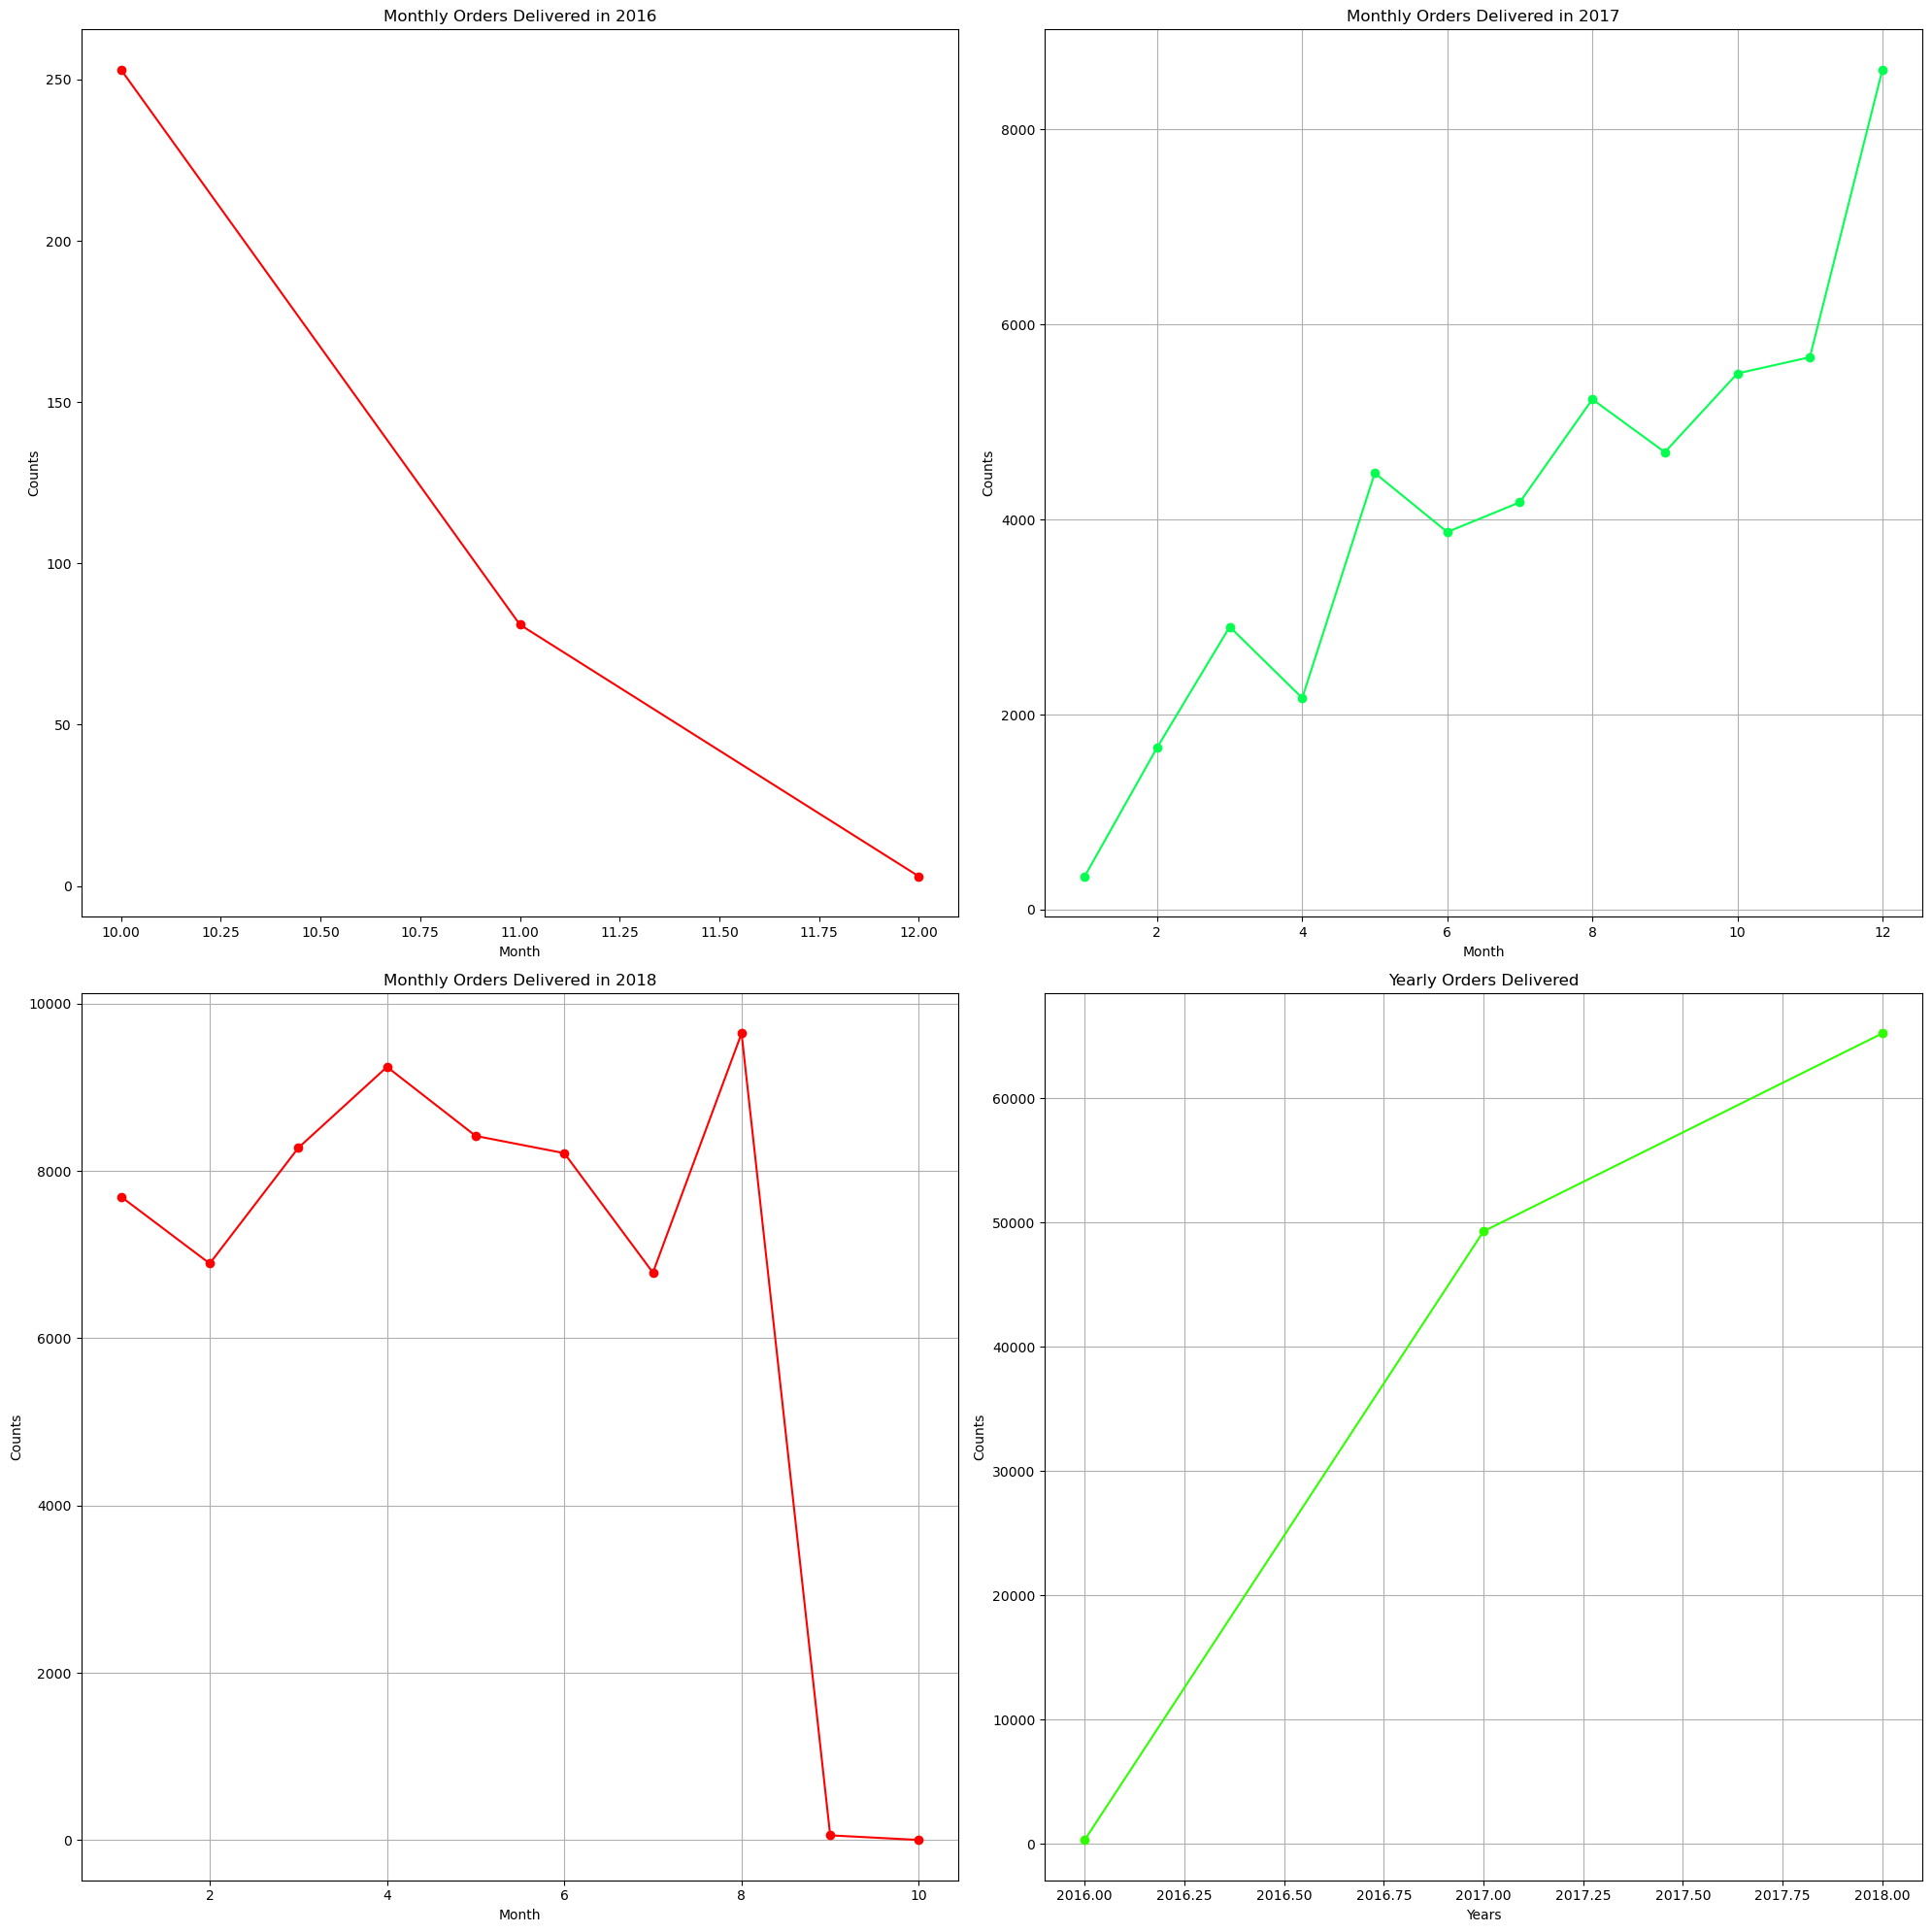

In [29]:
fig = plt.subplots(2,2, figsize = (20,20))
plt.subplot(2,2,1)
plt.plot(rvdf16['order_delivered_customer_date'].dt.month, rvdf16['counts'], marker='o', color="#FF0000")
plt.title('Monthly Orders Delivered in 2016')
plt.xlabel('Month')
plt.ylabel('Counts')
plt.subplot(2,2,2)
plt.plot(rvdf17['order_delivered_customer_date'].dt.month, rvdf17['counts'], marker='o', color="#04FF50")
plt.grid(True)
plt.title('Monthly Orders Delivered in 2017')
plt.xlabel('Month')
plt.ylabel('Counts')
plt.subplot(2,2,3)
plt.plot(rvdf18['order_delivered_customer_date'].dt.month, rvdf18['counts'], marker='o', color="#FF0000")
plt.grid(True)
plt.title('Monthly Orders Delivered in 2018')
plt.xlabel('Month')
plt.ylabel('Counts')
plt.subplot(2,2,4)
plt.plot(rvdfy['order_delivered_customer_date'].dt.year, rvdfy['counts'], marker='o', color="#2FFF00")
plt.grid(True)
plt.title('Yearly Orders Delivered')
plt.xlabel('Years')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

In [30]:
"""Year 2017 showed exponential growth but year 2018 shows steep decline in the number of delivered orders."""

'Year 2017 showed exponential growth but year 2018 shows steep decline in the number of delivered orders.'

Monthly revenue generated every Year

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1038300081.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = rev_mon16, x='order_delivered_customer_date', y='payment_value', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1038300081.py:8: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(data = rev_mon16, x='order_delivered_customer_date', y='payment_value', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1038300081.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = rev_mon17, x='ord

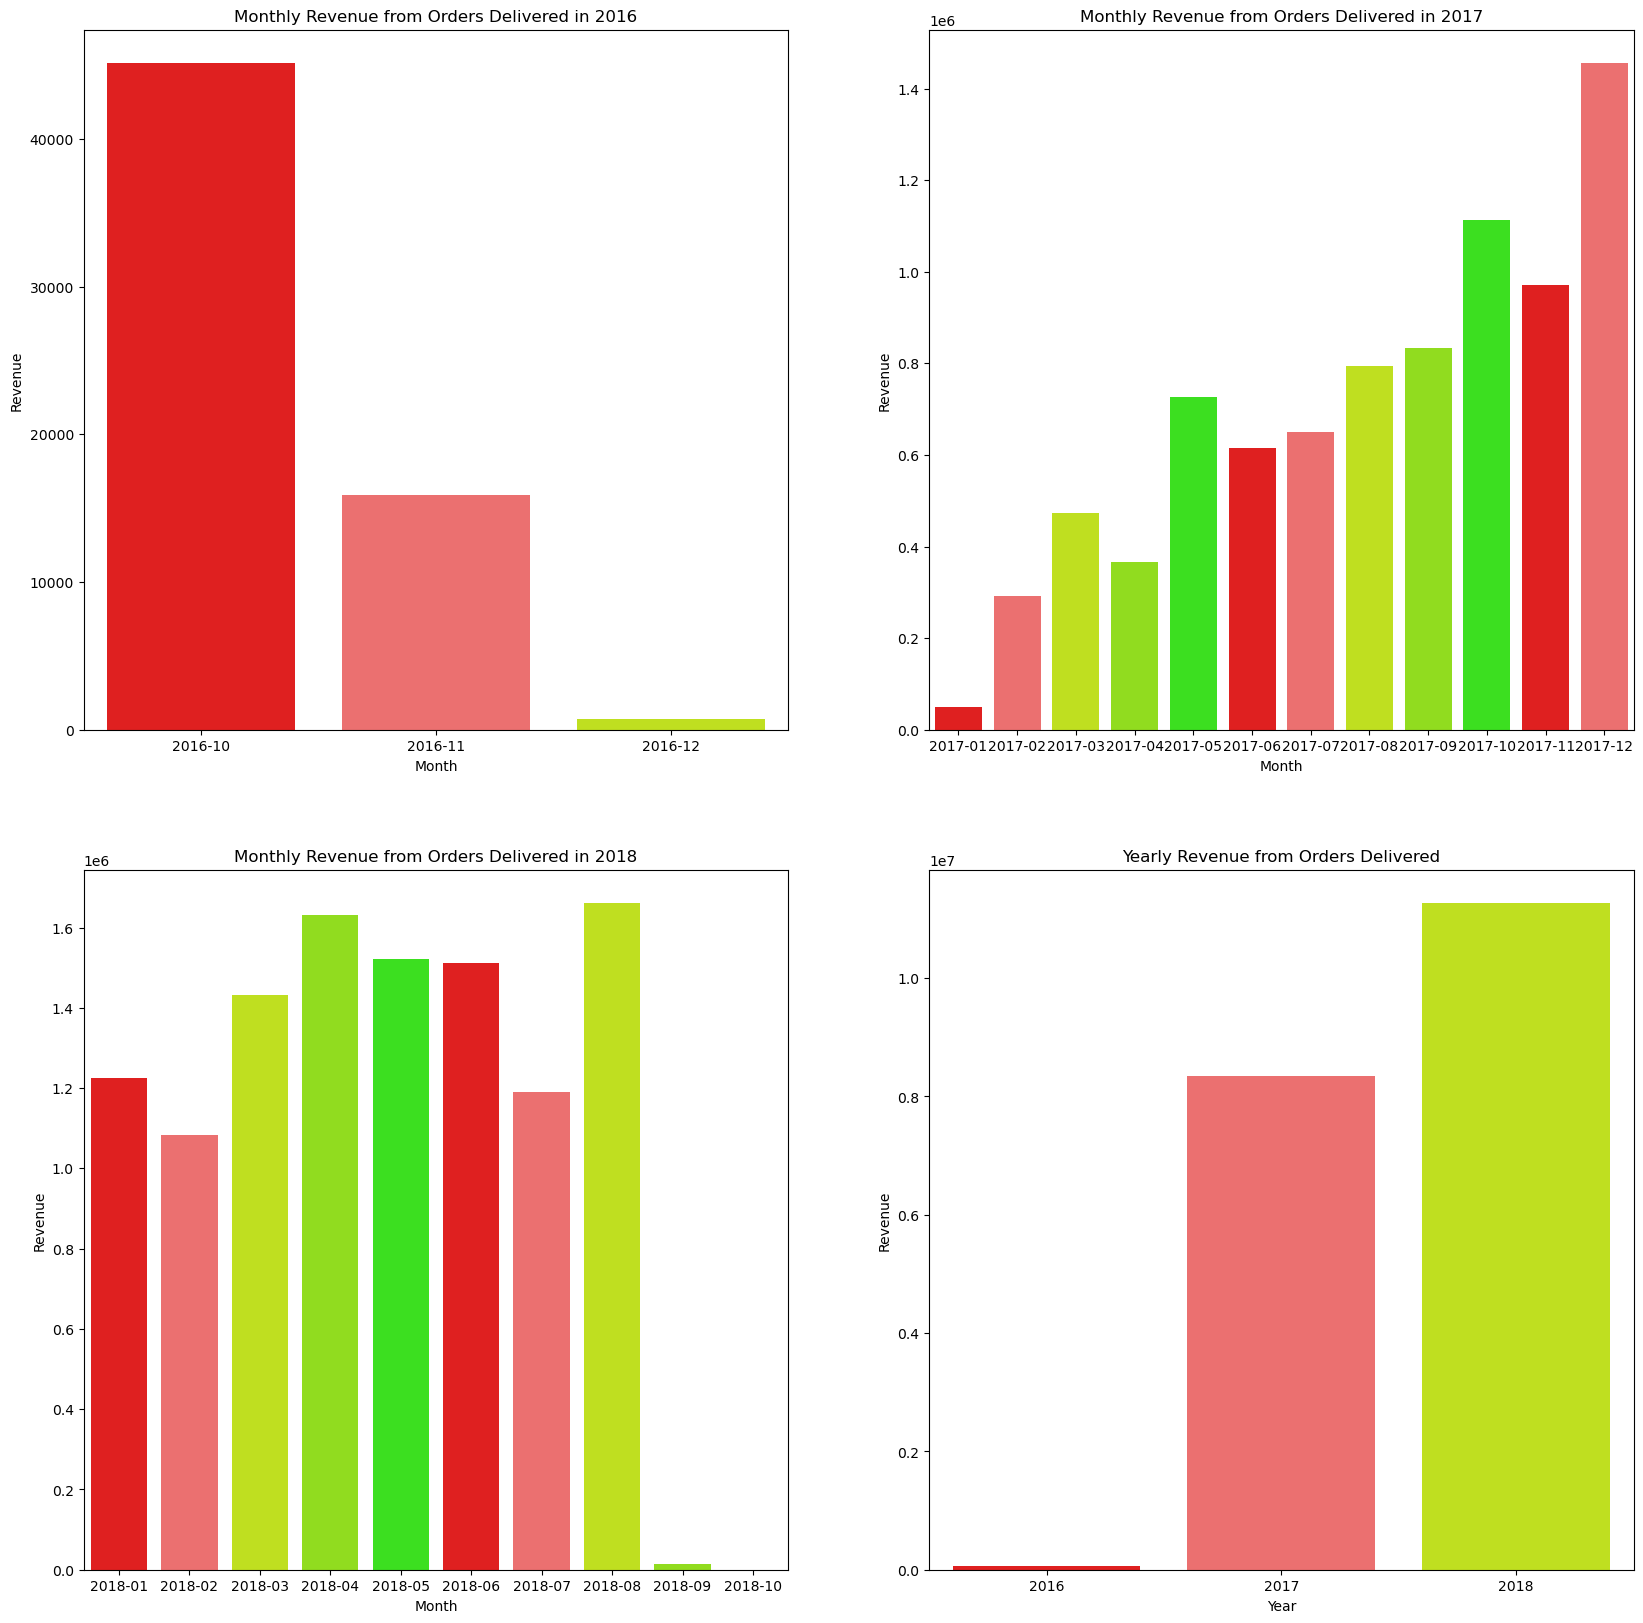

In [31]:
rev_y = df_train.groupby([df_train['order_delivered_customer_date'].dt.to_period('Y')]).sum('payment_value').reset_index('order_delivered_customer_date')
rev_mon = df_train.groupby([df_train['order_delivered_customer_date'].dt.to_period('M')]).sum('payment_value').reset_index('order_delivered_customer_date')
rev_mon16 = rev_mon[rev_mon['order_delivered_customer_date'].dt.year == 2016]
rev_mon17 = rev_mon[rev_mon['order_delivered_customer_date'].dt.year == 2017]
rev_mon18 = rev_mon[rev_mon['order_delivered_customer_date'].dt.year == 2018]
fig = plt.subplots(2,2, figsize = (20,20))
plt.subplot(2,2,1)
sns.barplot(data = rev_mon16, x='order_delivered_customer_date', y='payment_value', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
plt.title('Monthly Revenue from Orders Delivered in 2016')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.subplot(2,2,2)
sns.barplot(data = rev_mon17, x='order_delivered_customer_date', y='payment_value', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
plt.title('Monthly Revenue from Orders Delivered in 2017')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.subplot(2,2,3)
sns.barplot(data = rev_mon18, x='order_delivered_customer_date', y='payment_value', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
plt.title('Monthly Revenue from Orders Delivered in 2018')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.subplot(2,2,4)
sns.barplot(data = rev_y, x='order_delivered_customer_date', y='payment_value', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
plt.title('Yearly Revenue from Orders Delivered')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

Revenue over time

Text(0.5, 1.0, 'Revenue over time')

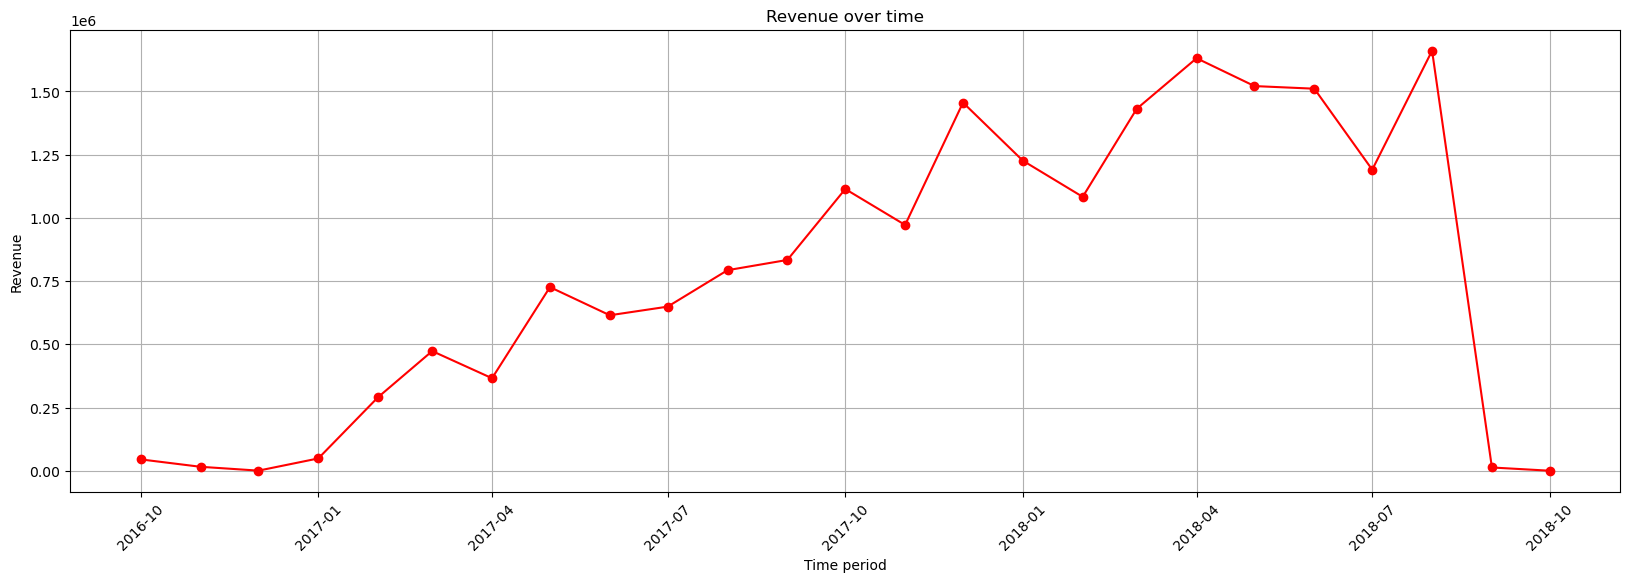

In [32]:
rgom = df_train.groupby([df_train['order_delivered_customer_date'].dt.to_period('M')])['payment_value'].sum().reset_index()
plt.figure(figsize=(20,6))
plt.plot(rgom['order_delivered_customer_date'].dt.to_timestamp(), rgom['payment_value'], marker='o', color = 'red')
plt.xticks(rotation=45)
plt.grid(True)
plt.xlabel("Time period")
plt.ylabel("Revenue")
plt.title("Revenue over time")

In [33]:
"""The revenue generation shows a peak decline in 2018 month 09 and 10 specifically"""

'The revenue generation shows a peak decline in 2018 month 09 and 10 specifically'

In [34]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117329 entries, 0 to 118309
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       117329 non-null  object         
 1   customer_id                    117329 non-null  object         
 2   order_status                   117329 non-null  object         
 3   order_purchase_timestamp       117329 non-null  datetime64[ns] 
 4   order_approved_at              117314 non-null  datetime64[ns] 
 5   order_delivered_carrier_date   116094 non-null  datetime64[ns] 
 6   order_delivered_customer_date  114858 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  117329 non-null  datetime64[ns] 
 8   order_item_id                  117329 non-null  float64        
 9   product_id                     117329 non-null  object         
 10  seller_id                      117329 non-null  object       

Number Of Late Deliveries

In [35]:
comd = df_train.query("order_estimated_delivery_date > order_delivered_customer_date")['order_id']
acomd = comd.value_counts()
acomds = acomd.sum()
comdn = df_train.query("order_estimated_delivery_date < order_delivered_customer_date")['order_id']
acomdn = comdn.value_counts()
acomdns = acomdn.sum()
df_comd = pd.DataFrame({'Deliveries': [acomds, acomdns]}, index=['On_Time', 'Late'])
df_comd

,Deliveries
On_Time,105998
Late,8860


Text(0.5, 1.0, 'Proportion of On-Time vs Late Deliveries')

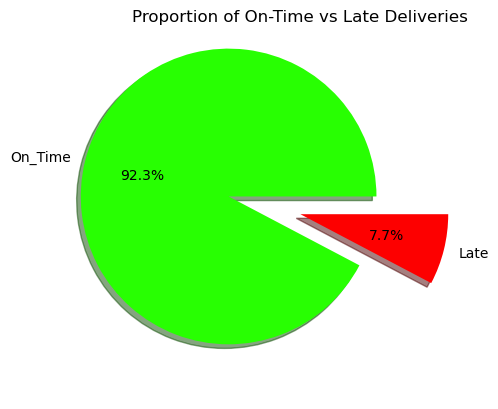

In [36]:
plt.pie(df_comd['Deliveries'], labels=df_comd.index, autopct='%1.1f%%', colors=[ "#28FF02", "#FD0000"], explode=(0.5, 0),shadow=True)
plt.title('Proportion of On-Time vs Late Deliveries')

In [37]:
"""The number of late deliveries is quite low."""

'The number of late deliveries is quite low.'

State wise analysis of late deliveries

In [38]:
nld = df_train.query("order_estimated_delivery_date < order_delivered_customer_date")
nldg = nld.groupby(nld['customer_state']).size().reset_index(name='counts')

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\3471822437.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = nld, x='customer_state', palette = "Set2")


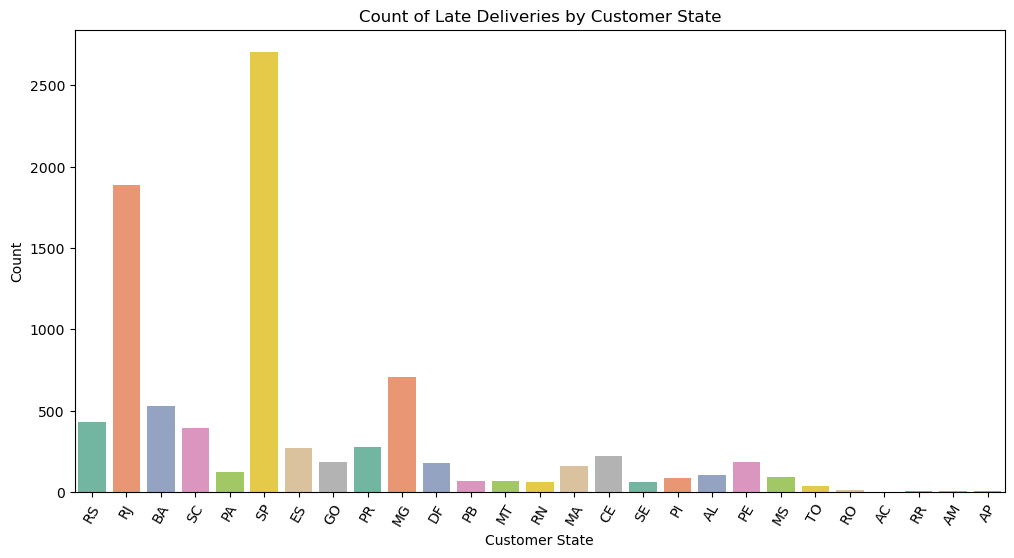

In [39]:
plt.figure(figsize=(12,6))
sns.countplot(data = nld, x='customer_state', palette = "Set2")
plt.title('Count of Late Deliveries by Customer State')
plt.xlabel('Customer State')
plt.ylabel('Count')
plt.xticks(rotation=60)
plt.show()

In [40]:
"""SP saw a major delay in deliveries along with Rj and MG"""

'SP saw a major delay in deliveries along with Rj and MG'

City wise analysis of the state with most late deliveries

In [41]:
cnld = nld.query("customer_state == 'SP'")
cnldg = cnld.groupby(cnld['customer_city']).size().reset_index(name='counts')
cnldgs = cnldg.sort_values(by='counts', ascending=False).head(10)
cnldgs

,customer_city,counts
217,sao paulo,1091
47,campinas,159
90,guarulhos,77
207,santos,68
208,sao bernardo do campo,67
216,sao jose dos campos,43
154,osasco,37
123,jundiai,37
206,santo andre,33
176,praia grande,33


C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1681322386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = cnldgs, x='customer_city', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1681322386.py:2: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data = cnldgs, x='customer_city', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])


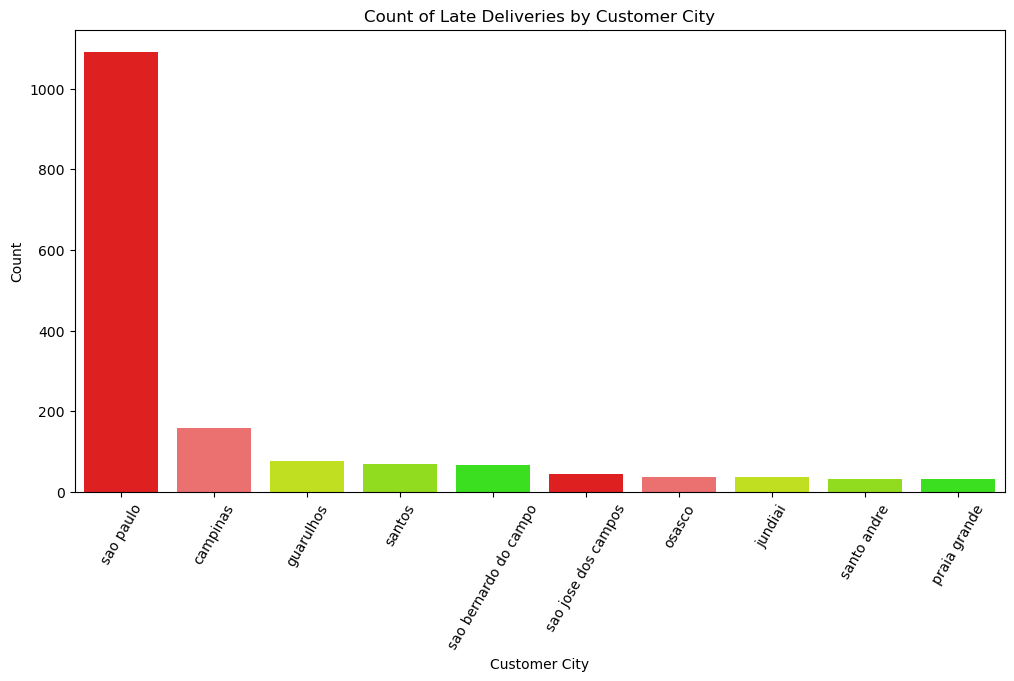

In [42]:
plt.figure(figsize=(12,6))
sns.barplot(data = cnldgs, x='customer_city', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#26FF00"])
plt.title('Count of Late Deliveries by Customer City')
plt.xlabel('Customer City')
plt.ylabel('Count')
plt.xticks(rotation=60)
plt.show()

In [43]:
"""In SP the largest delayed orders were seen by Sao Paulo"""

'In SP the largest delayed orders were seen by Sao Paulo'

In [44]:
nld.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'Delivery_time'],
      dtype='object')

Relationship between product weight and delivery delay

In [45]:
wnl = nld.groupby(nld['product_weight_g']).size().reset_index(name='counts')
wnld = wnl.drop(wnl[wnl['product_weight_g'] == 'Unknown'].index)

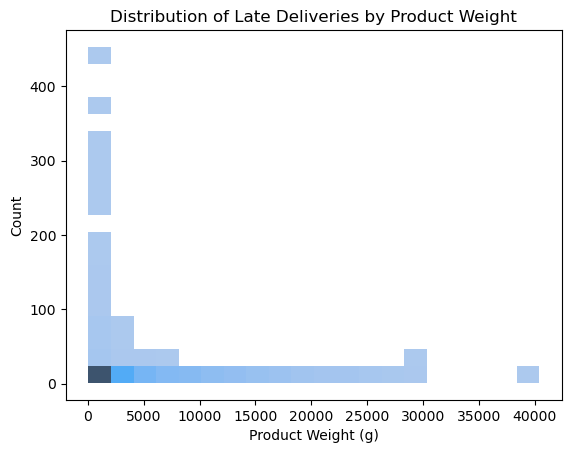

In [46]:
sns.histplot(data = wnld, x='product_weight_g', y='counts', bins=20,)
plt.title('Distribution of Late Deliveries by Product Weight')
plt.xlabel('Product Weight (g)')
plt.ylabel('Count')
plt.show()

In [47]:
"""Product weight doesnt seem to have an effect on late deliveries"""

'Product weight doesnt seem to have an effect on late deliveries'

In [48]:
vnld = nld['product_length_cm'] * nld['product_width_cm'] * nld['product_height_cm']
nld['product_volume_cm3'] = vnld 
gvnld = nld.groupby(nld['product_volume_cm3']).size().reset_index(name='counts')
gvnlds = gvnld.sort_values(by='counts', ascending=False).head(10)
gvnlds

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1496315466.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nld['product_volume_cm3'] = vnld


,product_volume_cm3,counts
623,8000.0,197
0,352.0,168
1027,19800.0,132
29,816.0,106
209,2560.0,95
1106,23625.0,93
987,18000.0,86
906,15000.0,68
1154,27000.0,64
501,6000.0,63


C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1473286143.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = gvnlds, x='product_volume_cm3', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#FF0000"])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1473286143.py:1: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data = gvnlds, x='product_volume_cm3', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#FF0000"])


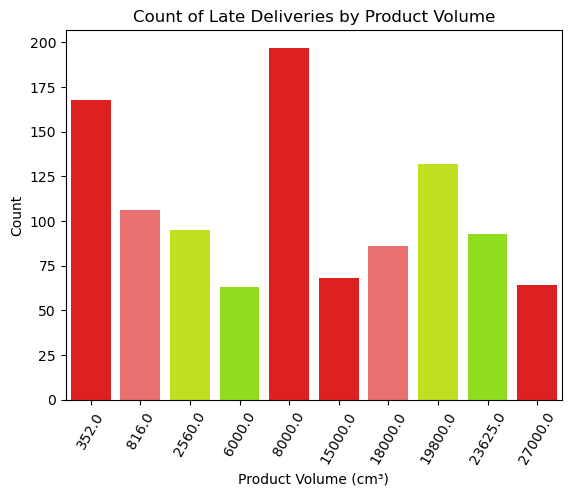

In [49]:
sns.barplot(data = gvnlds, x='product_volume_cm3', y='counts', palette = ["#FF0000","#FF5B5B","#D4FF00","#97FB00", "#FF0000"])
plt.title('Count of Late Deliveries by Product Volume')
plt.xlabel('Product Volume (cm³)')
plt.ylabel('Count')
plt.xticks(rotation=60)
plt.show()

In [50]:
"""All range of product volumes saw delays but 8000cm**3 saw major delayes. although they dont seem to be the cause of delay."""

'All range of product volumes saw delays but 8000cm**3 saw major delayes. although they dont seem to be the cause of delay.'

In [51]:
nld.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8860 entries, 40 to 118284
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       8860 non-null   object         
 1   customer_id                    8860 non-null   object         
 2   order_status                   8860 non-null   object         
 3   order_purchase_timestamp       8860 non-null   datetime64[ns] 
 4   order_approved_at              8860 non-null   datetime64[ns] 
 5   order_delivered_carrier_date   8859 non-null   datetime64[ns] 
 6   order_delivered_customer_date  8860 non-null   datetime64[ns] 
 7   order_estimated_delivery_date  8860 non-null   datetime64[ns] 
 8   order_item_id                  8860 non-null   float64        
 9   product_id                     8860 non-null   object         
 10  seller_id                      8860 non-null   object         
 11  shippi

Relationship between delivery delay and review score


C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\2260821881.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nld['delay'] = delay


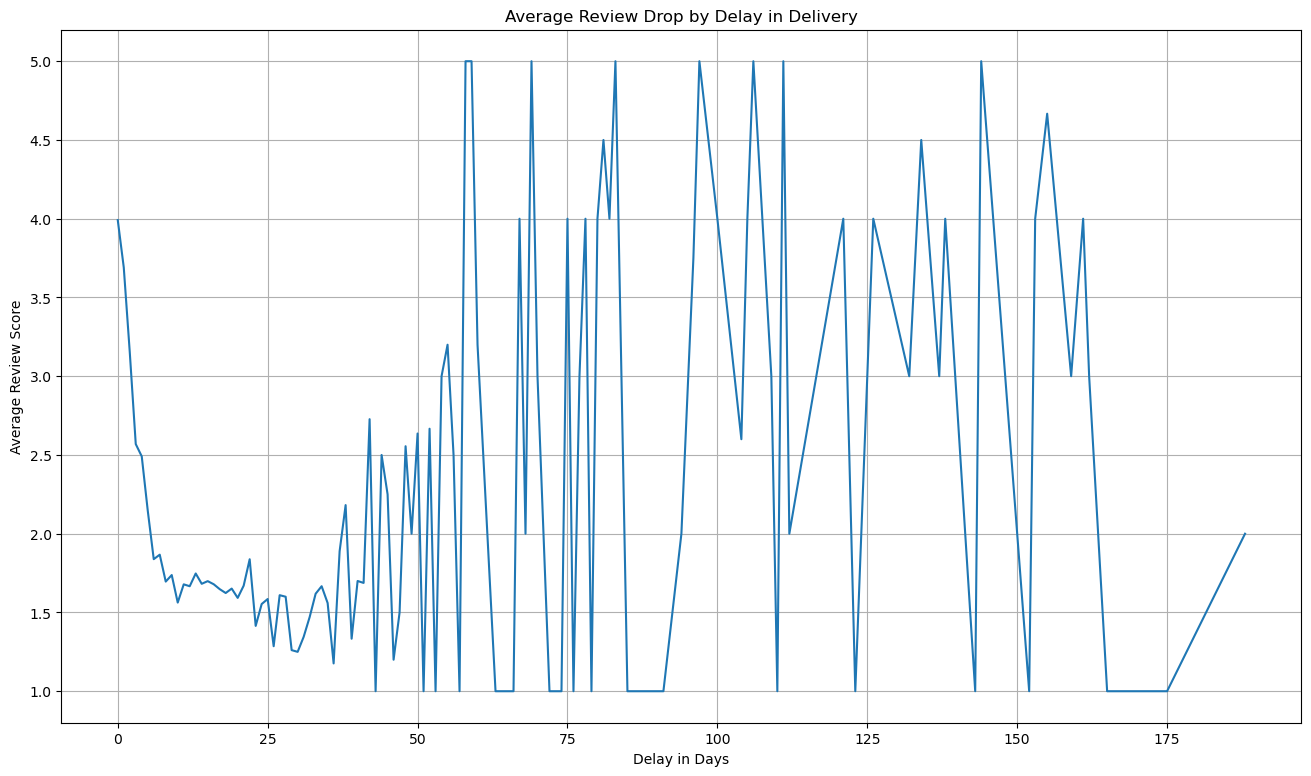

In [52]:


delay = (nld['order_delivered_customer_date'] - nld['order_estimated_delivery_date']).dt.days

nld['delay'] = delay


average_review_drop = nld.groupby('delay')['review_score'].mean().reset_index()

plt.figure(figsize=(16, 9))
sns.lineplot (x='delay', y='review_score', data = average_review_drop)
plt.title('Average Review Drop by Delay in Delivery')
plt.xlabel('Delay in Days')
plt.ylabel('Average Review Score')
plt.grid(True)
plt.show()

In [53]:
"""The delay in delivery definetely garners bad reviews."""

'The delay in delivery definetely garners bad reviews.'

In [54]:
nld.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8860 entries, 40 to 118284
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       8860 non-null   object         
 1   customer_id                    8860 non-null   object         
 2   order_status                   8860 non-null   object         
 3   order_purchase_timestamp       8860 non-null   datetime64[ns] 
 4   order_approved_at              8860 non-null   datetime64[ns] 
 5   order_delivered_carrier_date   8859 non-null   datetime64[ns] 
 6   order_delivered_customer_date  8860 non-null   datetime64[ns] 
 7   order_estimated_delivery_date  8860 non-null   datetime64[ns] 
 8   order_item_id                  8860 non-null   float64        
 9   product_id                     8860 non-null   object         
 10  seller_id                      8860 non-null   object         
 11  shippi

Finding product categories with most negative reviews

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1653412439.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category_name', y='count', data=rang, palette = ["#FF5100", "#9C0909", "#CB9202", "#E2870F", '#FFD700', "#FFD92F"])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\1653412439.py:7: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='product_category_name', y='count', data=rang, palette = ["#FF5100", "#9C0909", "#CB9202", "#E2870F", '#FFD700', "#FFD92F"])


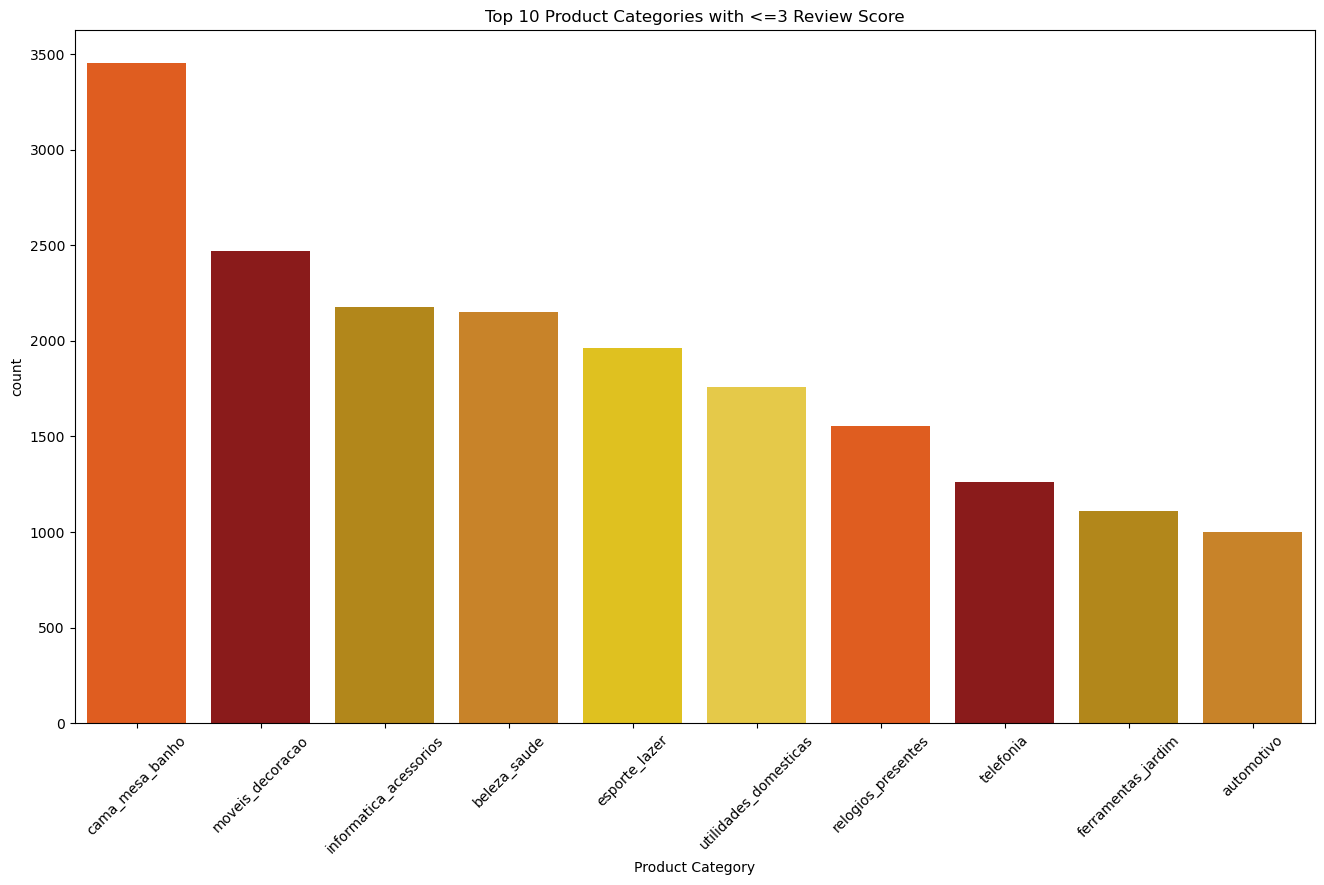

In [55]:
ran = df_train.query("review_score <= 3")
rang = ran.groupby('product_category_name')['review_score'].count().reset_index()
rang = rang.sort_values(by='review_score', ascending=False)
rang = rang.head(10)
rang.rename(columns={'review_score': 'count'},inplace = True)
plt.figure(figsize = (16,9))
sns.barplot(x='product_category_name', y='count', data=rang, palette = ["#FF5100", "#9C0909", "#CB9202", "#E2870F", '#FFD700', "#FFD92F"])
plt.xticks(rotation=45)
plt.title("Top 10 Product Categories with <=3 Review Score")
plt.xlabel('Product Category')
plt.show()

In [56]:
"""These product had worst ratings and need to be handled."""

'These product had worst ratings and need to be handled.'

Product cateategories with most positive reviews

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\2498428682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category_name', y='count', data=rang, palette = ["#3DB701", "#D1BD04", "#999903", "#EA8800", "#FFAA00", '#ADFF2F'])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\2498428682.py:7: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='product_category_name', y='count', data=rang, palette = ["#3DB701", "#D1BD04", "#999903", "#EA8800", "#FFAA00", '#ADFF2F'])


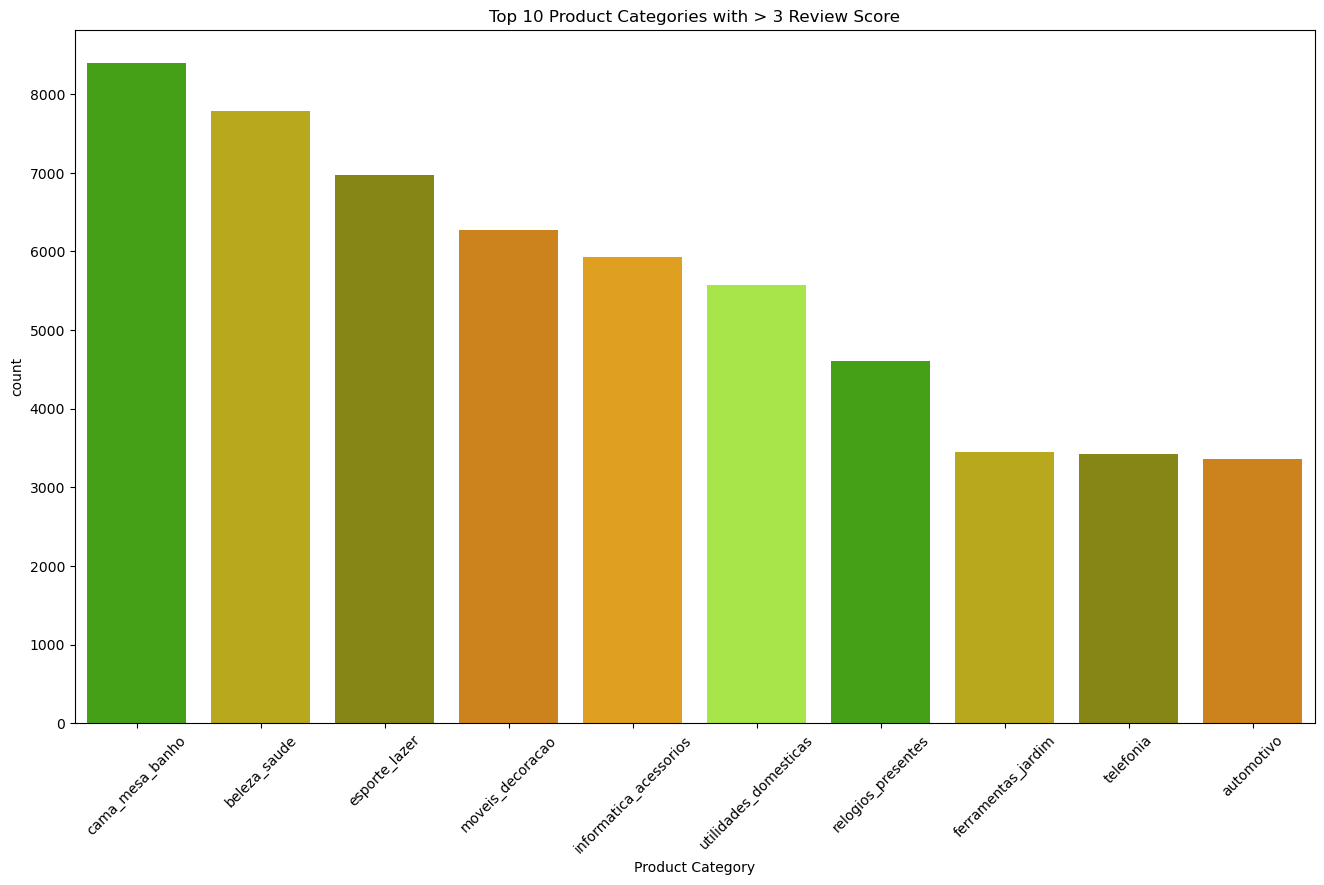

In [57]:
ran = df_train.query("review_score > 3")
rang = ran.groupby('product_category_name')['review_score'].count().reset_index()
rang = rang.sort_values(by='review_score', ascending=False)
rang = rang.head(10)
rang.rename(columns={'review_score': 'count'},inplace = True)
plt.figure(figsize = (16,9))
sns.barplot(x='product_category_name', y='count', data=rang, palette = ["#3DB701", "#D1BD04", "#999903", "#EA8800", "#FFAA00", '#ADFF2F'])
plt.xticks(rotation=45)
plt.title("Top 10 Product Categories with > 3 Review Score")
plt.xlabel('Product Category')
plt.show()

In [58]:
"""These products garnered the best reviews."""

'These products garnered the best reviews.'

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\873897756.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category_name', y='count', data=msld, palette = ["#3DB701", "#D1BD04", "#999903", "#FFAA00", '#ADFF2F'])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\873897756.py:6: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='product_category_name', y='count', data=msld, palette = ["#3DB701", "#D1BD04", "#999903", "#FFAA00", '#ADFF2F'])


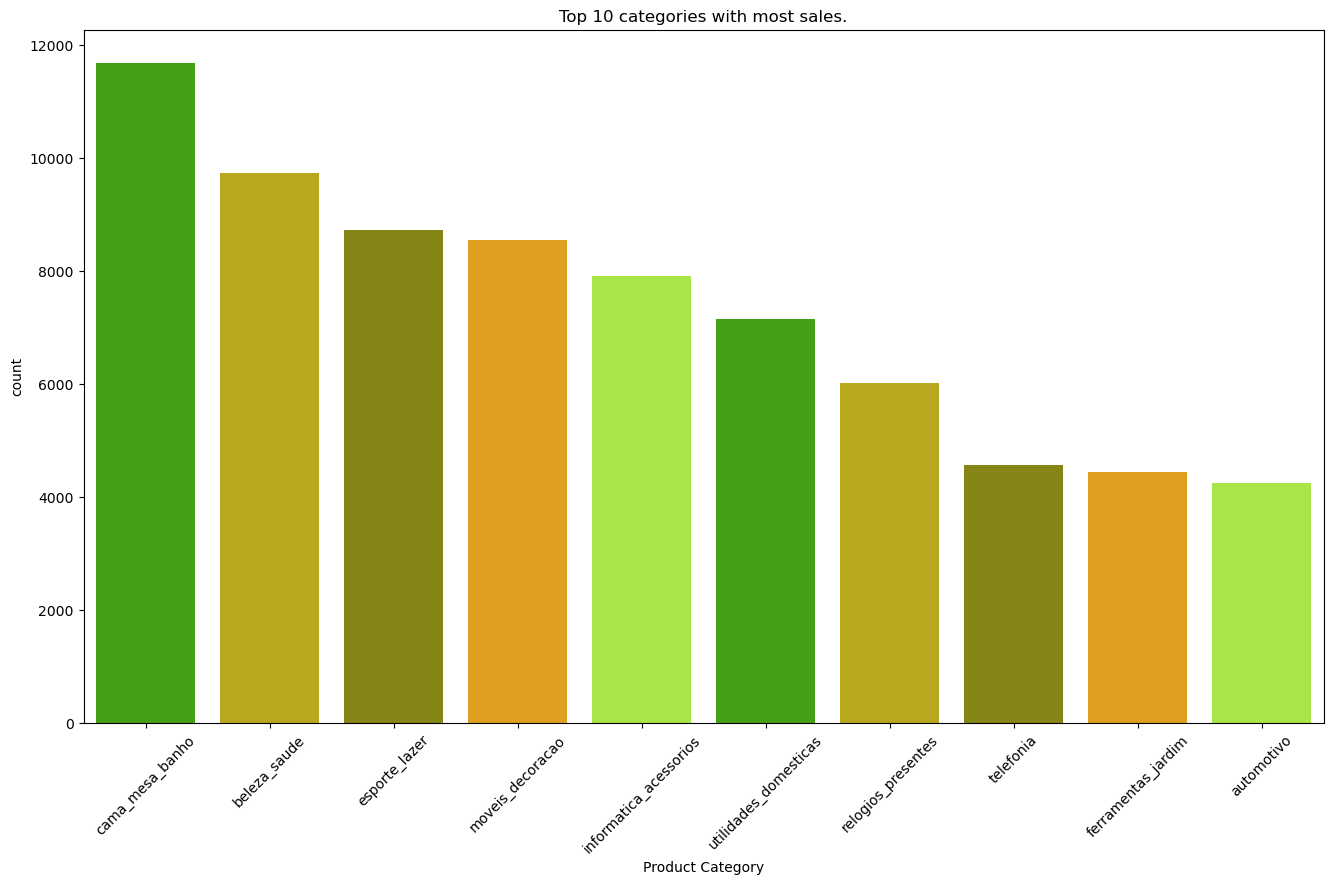

In [59]:
msld = df_train.groupby('product_category_name')['order_delivered_customer_date'].count().reset_index()
msld = msld.sort_values(by='order_delivered_customer_date', ascending=False)
msld = msld.head(10)
msld.rename(columns={'order_delivered_customer_date': 'count'},inplace = True)
plt.figure(figsize=(16,9))
sns.barplot(x='product_category_name', y='count', data=msld, palette = ["#3DB701", "#D1BD04", "#999903", "#FFAA00", '#ADFF2F'])
plt.title("Top 10 categories with most sales.")
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.show()


In [60]:
"""These category items were sold the most"""

'These category items were sold the most'

C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\2222881207.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category_name', y='count', data=msld, palette = ["#FA1818", "#D18A0E", "#C22D04", "#D64806", "#FFC12F"])
C:\Users\aksh3\AppData\Local\Temp\ipykernel_11776\2222881207.py:6: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='product_category_name', y='count', data=msld, palette = ["#FA1818", "#D18A0E", "#C22D04", "#D64806", "#FFC12F"])


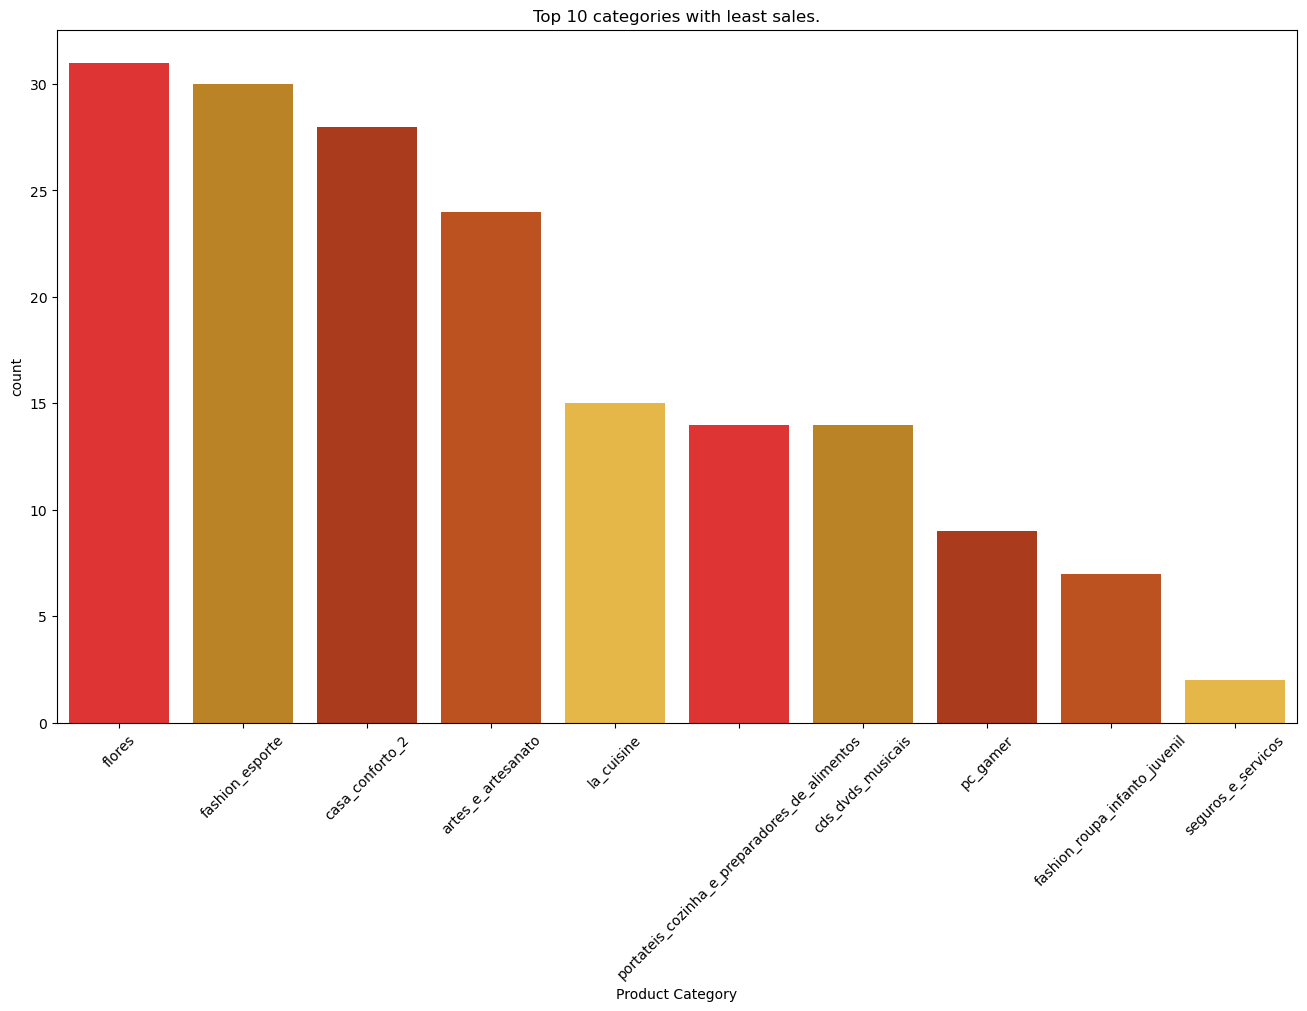

In [61]:
msld = df_train.groupby('product_category_name')['order_delivered_customer_date'].count().reset_index()
msld = msld.sort_values(by='order_delivered_customer_date', ascending=False)
msld = msld.tail(10)
msld.rename(columns={'order_delivered_customer_date': 'count'},inplace = True)
plt.figure(figsize=(16,9))
sns.barplot(x='product_category_name', y='count', data=msld, palette = ["#FA1818", "#D18A0E", "#C22D04", "#D64806", "#FFC12F"])
plt.title("Top 10 categories with least sales.")
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.show()


In [62]:
"""These category items were sold the least"""

'These category items were sold the least'

In [63]:
df_train.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'Delivery_time'],
      dtype='object')

Text(0.5, 1.0, 'Percentage of repeat customers')

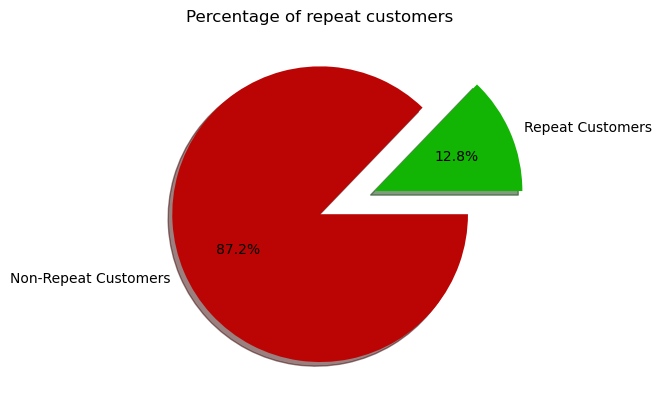

In [64]:
cra = df_train.groupby('customer_id')['order_delivered_customer_date'].count().reset_index()
cra.rename(columns={'order_delivered_customer_date': 'count'},inplace=True)
cra1 = cra.query('count >= 2')
cra2 = cra.query('count < 2')
x = len(cra1)
y = len(cra2)
l = [x,y]
plt.pie(l, labels=["Repeat Customers", "Non-Repeat Customers"], autopct='%1.1f%%', shadow=True, colors = ["#13B504", "#BB0505"], explode =(0.4,0))
plt.title("Percentage of repeat customers")



In [65]:
"""The percentage of Repeat customers is very low."""

'The percentage of Repeat customers is very low.'